# 18. From Scores, Segments, and Model Outputs to Operational Recommendations

A predictive model does not directly tell an organization what to do. It produces information. The decision layer comes afterward: which cases should be reviewed, which should be escalated, and when does acting cost more than it helps? This notebook turns model scores into an operational recommendation policy under explicit capacity and cost constraints.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Distinguish predictive accuracy from decision quality.
2. Translate a risk score into an expected-value recommendation.
3. Explain why the same score can imply different actions across segments.
4. Compare score-only, heuristic, and value-aware policies under capacity constraints.
5. Summarize a model-guided operational recommendation in terms decision-makers can defend.

## 1. Core Mathematical Ideas

Suppose case $i$ has breach probability $p_i$, loss if the breach occurs $L_i$, and an intervention $a$ that reduces risk by a fraction $e_i(a)$ while costing $C_i(a)$.

The expected value of taking action $a$ rather than doing nothing is

$$
V_i(a) = p_i \, e_i(a) \, L_i - C_i(a).
$$

This equation is the bridge from prediction to recommendation. A score matters only because it changes the expected value of acting.

If the intervention has a single fixed effectiveness $e$ and a single fixed cost $C$, then the action is worthwhile whenever

$$
p_i > \frac{C}{eL_i}.
$$

That is the **break-even threshold**. It already reveals an important decision-science fact: if losses differ by segment, then the break-even threshold differs by segment too. A 20% risk may justify action for one customer segment and not for another.

With a finite action budget, we face a constrained optimization problem. If only $K$ cases can receive the action, then a natural policy is

$$
\max_{\pi} \sum_{i=1}^n \pi_i V_i(a)
\quad \text{subject to} \quad \sum_{i=1}^n \pi_i \le K,
$$

where $\pi_i \in \{0,1\}$ indicates whether case $i$ is selected.

Under a single action and additive utility, the optimal policy is to rank cases by expected value and take the top $K$ positive ones. This is not necessarily the same as ranking only by risk score.

A related idea from decision curve analysis is **net benefit**. For a threshold policy with threshold probability $p_t$,

$$
\mathrm{NB}(p_t) = \frac{TP}{n} - \frac{FP}{n}\frac{p_t}{1-p_t}.
$$

Net benefit is useful because it converts sensitivity-specificity tradeoffs into decision units. But once we allow segment-specific losses, multiple actions, and capacity limits, we need a richer recommendation layer than a single universal threshold alone (Vickers et al., 2016; Sadatsafavi et al., 2021).

In [1]:
# Section focus: 1. Core Mathematical Ideas.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)


def logistic(x):
    """Carry out the logistic step used in the 18. From Scores, Segments, and Model Outputs to Operational Recommendations workflow.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Intermediate result produced by the logistic calculation and reused by later cells.
    """
    return 1 / (1 + np.exp(-x))


def safe_auc(y_true, score):
    """Carry out the safe auc step used in the 18. From Scores, Segments, and Model Outputs to Operational Recommendations workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the safe auc calculation.
    """
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, score)


def safe_ap(y_true, score):
    """Carry out the safe ap step used in the 18. From Scores, Segments, and Model Outputs to Operational Recommendations workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the safe ap calculation.
    """
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return average_precision_score(y_true, score)

## 2. Operational Setting

We will use the same seller-support environment as the previous notebook, but now our focus is not on monitoring drift. Our focus is recommendation design.

The model is trained on the stable historical phase. The current decision cohort is the **last week of the concept-drift phase**. This is a useful decision setting because the deployed model is no longer perfectly aligned to the environment, yet the organization still has to act.

In [2]:
# Section focus: 2. Operational Setting.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def simulate_support_environment(n_sellers=180, n_days=220, random_state=2026):
    """Create a simulated support environment data set for the 18. From Scores, Segments, and Model Outputs to Operational Recommendations case study.
    
    Parameters
    ----------
    n_sellers : object
        Count or size setting for the support environment calculation.
    n_days : object
        Count or size setting for the support environment calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)

    seller_ids = np.arange(n_sellers)
    tiers = rng.choice(["SMB", "Mid-Market", "Enterprise"], size=n_sellers, p=[0.5, 0.32, 0.18])
    regions = rng.choice(["North America", "Europe", "APAC"], size=n_sellers, p=[0.46, 0.29, 0.25])
    channels = rng.choice(["Email", "Chat", "Phone"], size=n_sellers, p=[0.45, 0.35, 0.20])
    analyst_experience = np.clip(rng.normal(4.8, 1.6, size=n_sellers), 0.5, 10.0)
    base_risk = rng.normal(0.0, 1.0, size=n_sellers)
    migration_prone = rng.binomial(1, 0.28, size=n_sellers)

    pressure_state = rng.normal(0.0, 0.55, size=n_sellers)
    backlog_state = np.clip(rng.normal(4.5, 1.2, size=n_sellers), 1.0, 9.0)

    def phase_name(day_idx):
        """Carry out the phase name step used in the 18. From Scores, Segments, and Model Outputs to Operational Recommendations workflow.
        
        Parameters
        ----------
        day_idx : object
            Integer day index used to locate a simulated event or observation.
        
        Returns
        -------
        object
            Intermediate result produced by the phase name calculation and reused by later cells.
        """
        if day_idx < 110:
            return "Stable train"
        if day_idx < 140:
            return "Stable deploy"
        if day_idx < 170:
            return "Covariate drift"
        if day_idx < 195:
            return "Concept drift"
        return "Feedback loop"

    dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
    records = []

    for day_idx, date in enumerate(dates):
        phase = phase_name(day_idx)
        weekend = int(date.weekday() >= 5)
        release_window = int(day_idx % 28 in [5, 6, 7])

        phase_pressure_shift = {
            "Stable train": 0.00,
            "Stable deploy": 0.00,
            "Covariate drift": 0.18,
            "Concept drift": 0.18,
            "Feedback loop": 0.18,
        }[phase]
        outage_probability = {
            "Stable train": 0.00,
            "Stable deploy": 0.00,
            "Covariate drift": 0.00,
            "Concept drift": 0.12,
            "Feedback loop": 0.12,
        }[phase]

        for seller_idx, seller_id in enumerate(seller_ids):
            tier = tiers[seller_idx]
            region = regions[seller_idx]
            channel = channels[seller_idx]
            experience = analyst_experience[seller_idx]
            seller_risk = base_risk[seller_idx]
            prior_pressure = pressure_state[seller_idx]
            prior_backlog = backlog_state[seller_idx]

            enterprise = int(tier == "Enterprise")
            apac = int(region == "APAC")
            email = int(channel == "Email")

            current_pressure = (
                0.92 * prior_pressure
                + rng.normal(0.0, 0.18)
                + 0.14 * weekend
                + 0.16 * release_window
                + 0.08 * seller_risk
                + phase_pressure_shift
            )

            workflow_migration_today = rng.binomial(
                1,
                min(
                    0.01
                    + 0.05 * migration_prone[seller_idx]
                    + 0.03 * enterprise
                    + 0.02 * apac
                    + 0.05 * release_window,
                    0.35,
                ),
            )
            vendor_outage_today = rng.binomial(1, outage_probability)

            tickets_mean = np.exp(
                0.85
                + 0.18 * seller_risk
                + 0.22 * current_pressure
                + 0.06 * prior_backlog
                + 0.06 * email
                + 0.22 * workflow_migration_today
            )
            tickets_opened = rng.poisson(min(tickets_mean, 18))

            queue_load = max(
                0.5,
                3.0
                + 0.9 * tickets_opened
                + 1.0 * max(current_pressure, 0)
                + 0.30 * prior_backlog
                + rng.normal(0.0, 0.7),
            )

            backlog_end = max(
                0.0,
                0.70 * prior_backlog
                + 0.22 * tickets_opened
                - (3.8 + 0.35 * experience + rng.normal(0.0, 0.6)),
            )

            resolution_minutes = max(
                12.0,
                42
                + 1.8 * tickets_opened
                + 4.5 * max(current_pressure, 0)
                + 1.4 * prior_backlog
                + 4.0 * enterprise
                + 2.5 * apac
                + 3.0 * seller_risk
                - 1.4 * experience
                + 8.0 * workflow_migration_today
                + 10.0 * vendor_outage_today
                + rng.normal(0.0, 4.0),
            )

            natural_logit = (
                -2.85
                + 0.45 * seller_risk
                + 0.60 * current_pressure
                + 0.04 * tickets_opened
                + 0.08 * prior_backlog
                + 0.006 * resolution_minutes
                + 0.55 * workflow_migration_today
                + 0.80 * vendor_outage_today
                + 0.08 * release_window
                + 0.08 * apac
                - 0.08 * experience
            )
            natural_prob = logistic(natural_logit)
            natural_breach = rng.binomial(1, natural_prob)

            records.append(
                {
                    "seller_id": seller_id,
                    "date": date,
                    "phase": phase,
                    "tier": tier,
                    "region": region,
                    "channel": channel,
                    "analyst_experience": experience,
                    "tickets_opened": tickets_opened,
                    "queue_load": queue_load,
                    "backlog_end": backlog_end,
                    "resolution_minutes": resolution_minutes,
                    "workflow_migration_today": workflow_migration_today,
                    "vendor_outage_today": vendor_outage_today,
                    "weekday": date.weekday(),
                    "natural_prob": natural_prob,
                    "natural_breach": natural_breach,
                }
            )

            pressure_state[seller_idx] = 0.90 * current_pressure + 0.12 * natural_breach + 0.02 * (queue_load / 10)
            backlog_state[seller_idx] = np.clip(backlog_end, 0.0, 16.0)

    return pd.DataFrame(records)


def build_feature_matrix(df):
    """Build the feature matrix object used in the 18. From Scores, Segments, and Model Outputs to Operational Recommendations analysis.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the feature matrix workflow for later analysis.
    """
    feature_df = df.sort_values(["seller_id", "date"]).copy()
    grouped = feature_df.groupby("seller_id", group_keys=False)

    feature_df["prior_backlog"] = grouped["backlog_end"].shift(1)
    feature_df["prior_queue_load"] = grouped["queue_load"].shift(1)
    feature_df["prior_tickets"] = grouped["tickets_opened"].shift(1)

    feature_df["backlog_7d_mean"] = grouped["backlog_end"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["queue_7d_mean"] = grouped["queue_load"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["tickets_7d_mean"] = grouped["tickets_opened"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["breach_rate_7d"] = grouped["natural_breach"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)
    feature_df["resolution_7d_mean"] = grouped["resolution_minutes"].shift(1).rolling(7, min_periods=2).mean().reset_index(level=0, drop=True)

    feature_df["recent_backlog_jump"] = feature_df["prior_backlog"] - feature_df["backlog_7d_mean"]
    feature_df["queue_pressure_gap"] = feature_df["prior_queue_load"] - feature_df["queue_7d_mean"]

    feature_df["weekday_sin"] = np.sin(2 * np.pi * feature_df["weekday"] / 7)
    feature_df["weekday_cos"] = np.cos(2 * np.pi * feature_df["weekday"] / 7)

    return feature_df.dropna().reset_index(drop=True)


feature_df = build_feature_matrix(simulate_support_environment())
train_df = feature_df.loc[feature_df["phase"] == "Stable train"].copy()
concept_df = feature_df.loc[feature_df["phase"] == "Concept drift"].copy()
current_cutoff = concept_df["date"].max() - pd.Timedelta(days=6)
current_df = concept_df.loc[concept_df["date"] >= current_cutoff].copy().reset_index(drop=True)

feature_cols = [
    "tier",
    "region",
    "channel",
    "analyst_experience",
    "prior_backlog",
    "prior_queue_load",
    "prior_tickets",
    "backlog_7d_mean",
    "queue_7d_mean",
    "tickets_7d_mean",
    "breach_rate_7d",
    "resolution_7d_mean",
    "recent_backlog_jump",
    "queue_pressure_gap",
    "weekday_sin",
    "weekday_cos",
]

categorical_features = ["tier", "region", "channel"]
numeric_features = [col for col in feature_cols if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
    ]
)

risk_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(C=0.1, max_iter=2000)),
    ]
)

risk_model.fit(train_df[feature_cols], train_df["natural_breach"])
current_df["score"] = risk_model.predict_proba(current_df[feature_cols])[:, 1]

cohort_preview_cols = [
    "seller_id",
    "date",
    "tier",
    "region",
    "channel",
    "prior_queue_load",
    "backlog_7d_mean",
    "natural_prob",
    "score",
]
display(current_df[cohort_preview_cols].head())

,seller_id,date,tier,region,channel,prior_queue_load,backlog_7d_mean,natural_prob,score
0,0,2025-07-08,SMB,Europe,Chat,8.528476,0.0,0.201014,0.133996
1,0,2025-07-09,SMB,Europe,Chat,7.117393,0.0,0.336071,0.093028
2,0,2025-07-10,SMB,Europe,Chat,6.640354,0.0,0.138244,0.073692
3,0,2025-07-11,SMB,Europe,Chat,5.261524,0.0,0.262288,0.081639
4,0,2025-07-12,SMB,Europe,Chat,5.642688,0.0,0.145012,0.077811


The practical question in Operational Setting is simple. What would this result make the analyst do differently?


,quantity,value
0,Current decision cohort rows,1260
1,Date span,2025-07-08 to 2025-07-14
2,Observed breach rate in current cohort,18.6%
3,Average predicted risk,14.6%
4,ROC AUC,0.665
5,Average precision,0.303
6,Brier score,0.146


,tier,cases,avg_score,natural_breach_rate,avg_natural_prob
0,Enterprise,189,0.186399,0.216931,0.217854
1,Mid-Market,434,0.138589,0.182028,0.182863
2,SMB,637,0.138077,0.178964,0.180917


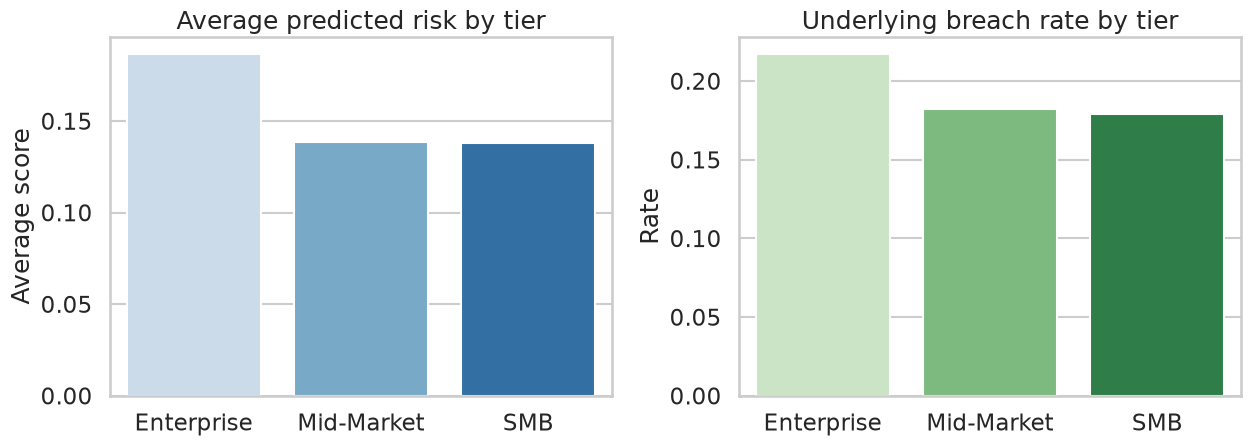

In [3]:
# Section focus: 2. Operational Setting.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

cohort_overview = pd.DataFrame(
    [
        {"quantity": "Current decision cohort rows", "value": len(current_df)},
        {"quantity": "Date span", "value": f"{current_df['date'].min().date()} to {current_df['date'].max().date()}"},
        {"quantity": "Observed breach rate in current cohort", "value": f"{current_df['natural_breach'].mean():.1%}"},
        {"quantity": "Average predicted risk", "value": f"{current_df['score'].mean():.1%}"},
        {"quantity": "ROC AUC", "value": f"{safe_auc(current_df['natural_breach'], current_df['score']):.3f}"},
        {"quantity": "Average precision", "value": f"{safe_ap(current_df['natural_breach'], current_df['score']):.3f}"},
        {"quantity": "Brier score", "value": f"{brier_score_loss(current_df['natural_breach'], current_df['score']):.3f}"},
    ]
)

display(cohort_overview)

tier_summary = (
    current_df.groupby("tier")
    .agg(
        cases=("seller_id", "size"),
        avg_score=("score", "mean"),
        natural_breach_rate=("natural_breach", "mean"),
        avg_natural_prob=("natural_prob", "mean"),
    )
    .reset_index()
)

display(tier_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(data=tier_summary, x="tier", y="avg_score", palette="Blues", ax=axes[0])
axes[0].set_title("Average predicted risk by tier")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average score")

sns.barplot(data=tier_summary, x="tier", y="natural_breach_rate", palette="Greens", ax=axes[1])
axes[1].set_title("Underlying breach rate by tier")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rate")

plt.tight_layout()
plt.show()

The model is useful but not exceptional. That is exactly the kind of score we care about in practice: strong enough to guide action, but imperfect enough that recommendation quality will depend on how thoughtfully we use it.

Use the Operational Setting output to decide what the analysis should do next. Treat the pattern as important only when it would change the workflow.


## 3. Decision Economics by Segment and Action

We will define two possible actions:

- **Review**: a lower-cost operational intervention.
- **Escalate**: a more expensive specialist intervention.

The business value of preventing a breach differs by seller tier. Enterprise accounts are more costly to fail than SMB accounts. Action effectiveness also varies by observed context such as channel and workload.

This means a recommendation policy should combine three ingredients:

1. the model score,
2. the business consequence of failure,
3. the expected effectiveness and cost of the action.

In [4]:
# Section focus: 3. Decision Economics by Segment and Action.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

current_df["high_workload"] = (
    current_df["prior_queue_load"] >= current_df["prior_queue_load"].quantile(0.75)
).astype(int)

breach_loss_map = {
    "SMB": 220.0,
    "Mid-Market": 520.0,
    "Enterprise": 1200.0,
}
current_df["breach_loss"] = current_df["tier"].map(breach_loss_map)

current_df["review_cost"] = 20.0
current_df["escalation_cost"] = 70.0

current_df["review_effect"] = (
    0.14
    + 0.05 * (current_df["channel"] == "Email")
    + 0.03 * (current_df["channel"] == "Chat")
    + 0.05 * current_df["high_workload"]
    + 0.03 * (current_df["tier"] == "Enterprise")
).clip(0.08, 0.40)

current_df["escalation_effect"] = (
    0.32
    + 0.08 * (current_df["tier"] == "Enterprise")
    + 0.05 * current_df["high_workload"]
    + 0.04 * (current_df["channel"] == "Phone")
    + 0.02 * (current_df["region"] == "APAC")
).clip(0.22, 0.65)

for prefix, risk_col in [("est", "score"), ("true", "natural_prob")]:
    current_df[f"ev_review_{prefix}"] = (
        current_df[risk_col] * current_df["review_effect"] * current_df["breach_loss"]
        - current_df["review_cost"]
    )
    current_df[f"ev_escalate_{prefix}"] = (
        current_df[risk_col] * current_df["escalation_effect"] * current_df["breach_loss"]
        - current_df["escalation_cost"]
    )

value_summary = (
    current_df.groupby("tier")
    .agg(
        avg_score=("score", "mean"),
        avg_true_risk=("natural_prob", "mean"),
        avg_loss=("breach_loss", "mean"),
        avg_review_value=("ev_review_est", "mean"),
        avg_escalation_value=("ev_escalate_est", "mean"),
    )
    .reset_index()
)

display(value_summary)

,tier,avg_score,avg_true_risk,avg_loss,avg_review_value,avg_escalation_value
0,Enterprise,0.186399,0.217854,1200.0,31.282768,27.219757
1,Mid-Market,0.138589,0.182863,520.0,-6.244690,-44.882120
2,SMB,0.138077,0.180917,220.0,-14.118138,-59.208416


Notice what happened. The model score is only one part of the recommendation. Even if two cases have similar predicted risk, the expected value of acting can differ because their losses and intervention effects differ.

These numbers translate model behavior into decision consequences. For Decision Economics by Segment and Action, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


## 4. Break-Even Thresholds Are Segment-Specific

If we rearrange the expected-value inequality, we get the break-even score threshold

$$
p_i^*(a) = \frac{C_i(a)}{e_i(a)L_i}.
$$

When losses or action effects vary by segment, $p_i^*(a)$ varies too. That means a universal threshold can be economically incoherent.

,tier,avg_review_effect,avg_escalation_effect,avg_loss,review_break_even_threshold,escalation_break_even_threshold
0,Enterprise,0.220741,0.427778,1200.0,0.075503,0.136364
1,Mid-Market,0.184700,0.342765,520.0,0.208237,0.392734
2,SMB,0.184270,0.347347,220.0,0.493347,0.916035


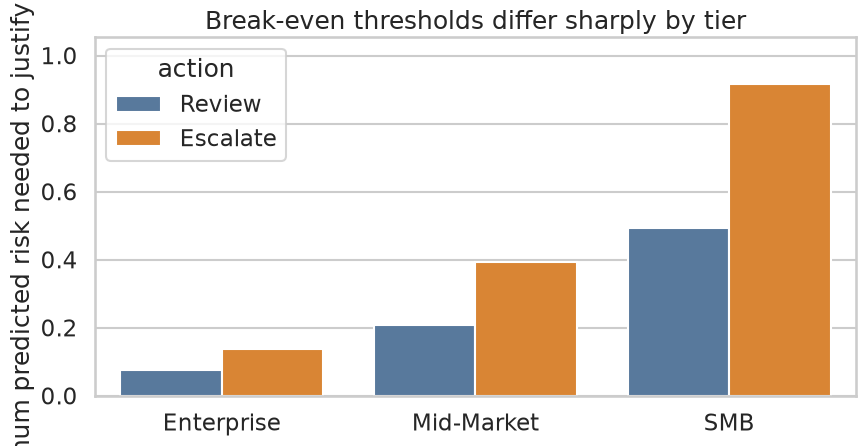

In [5]:
# Section focus: 4. Break-Even Thresholds Are Segment-Specific.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

segment_thresholds = (
    current_df.groupby("tier")
    .agg(
        avg_review_effect=("review_effect", "mean"),
        avg_escalation_effect=("escalation_effect", "mean"),
        avg_loss=("breach_loss", "mean"),
    )
    .reset_index()
)
segment_thresholds["review_break_even_threshold"] = (
    current_df["review_cost"].iloc[0]
    / (segment_thresholds["avg_review_effect"] * segment_thresholds["avg_loss"])
)
segment_thresholds["escalation_break_even_threshold"] = (
    current_df["escalation_cost"].iloc[0]
    / (segment_thresholds["avg_escalation_effect"] * segment_thresholds["avg_loss"])
)

display(segment_thresholds)

threshold_plot = segment_thresholds.melt(
    id_vars="tier",
    value_vars=["review_break_even_threshold", "escalation_break_even_threshold"],
    var_name="action",
    value_name="threshold",
)
threshold_plot["action"] = threshold_plot["action"].map(
    {
        "review_break_even_threshold": "Review",
        "escalation_break_even_threshold": "Escalate",
    }
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=threshold_plot, x="tier", y="threshold", hue="action", palette=["#4c78a8", "#f58518"], ax=ax)
ax.set_title("Break-even thresholds differ sharply by tier")
ax.set_xlabel("")
ax.set_ylabel("Minimum predicted risk needed to justify action")
ax.set_ylim(0, max(0.75, threshold_plot["threshold"].max() * 1.15))
plt.tight_layout()
plt.show()

This plot is one of the most important in the notebook. Enterprise cases justify intervention at much lower risk thresholds because the cost of a missed breach is larger. That is why a recommendation system that uses only scores can leave value on the table.

## 5. Compare Policy Designs Under Capacity Constraints

Assume the operations team has capacity for:

- `220` review actions,
- `80` specialist escalations.

We will compare four policies:

1. **Do nothing**.
2. **Queue-load heuristic**: allocate actions by workload only.
3. **Score-only policy**: allocate actions by model score only.
4. **Value-aware policy**: allocate actions by estimated expected value.

To evaluate them fairly in the notebook, we use the simulation's underlying risk as the oracle benchmark. That lets us isolate policy quality from noisy one-off realized outcomes.

In [6]:
# Section focus: 5. Compare Policy Designs Under Capacity Constraints.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

review_capacity = 220
escalation_capacity = 80


def assign_policy(df, policy_name):
    """Carry out the assign policy step used in the 18. From Scores, Segments, and Model Outputs to Operational Recommendations workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    policy_name : object
        The policy name setting that controls the assign policy calculation in this notebook.
    
    Returns
    -------
    object
        Decision recommendation or policy object produced by the assign policy workflow.
    """
    actions = pd.Series("none", index=df.index, dtype="object")

    if policy_name == "none":
        return actions

    if policy_name == "load":
        escalate_idx = df.sort_values("prior_queue_load", ascending=False).head(escalation_capacity).index
        remaining = df.drop(index=escalate_idx)
        review_idx = remaining.sort_values("prior_queue_load", ascending=False).head(review_capacity).index
    elif policy_name == "score":
        escalate_idx = df.sort_values("score", ascending=False).head(escalation_capacity).index
        remaining = df.drop(index=escalate_idx)
        review_idx = remaining.sort_values("score", ascending=False).head(review_capacity).index
    elif policy_name == "value":
        escalate_pool = df.loc[df["ev_escalate_est"] > 0].sort_values("ev_escalate_est", ascending=False)
        escalate_idx = escalate_pool.head(escalation_capacity).index
        remaining = df.drop(index=escalate_idx)
        review_pool = remaining.loc[remaining["ev_review_est"] > 0].sort_values("ev_review_est", ascending=False)
        review_idx = review_pool.head(review_capacity).index
    else:
        raise ValueError(f"Unknown policy: {policy_name}")

    actions.loc[escalate_idx] = "escalate"
    actions.loc[review_idx] = "review"
    return actions


def evaluate_policy(df, policy_name):
    """Evaluate policy for the 18. From Scores, Segments, and Model Outputs to Operational Recommendations decision workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    policy_name : object
        The policy name setting that controls the policy calculation in this notebook.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    actions = assign_policy(df, policy_name)

    utility = np.where(
        actions.eq("review"),
        df["ev_review_true"],
        np.where(actions.eq("escalate"), df["ev_escalate_true"], 0.0),
    )

    spend = np.where(
        actions.eq("review"),
        df["review_cost"],
        np.where(actions.eq("escalate"), df["escalation_cost"], 0.0),
    )

    prevented_breaches = np.where(
        actions.eq("review"),
        df["natural_prob"] * df["review_effect"],
        np.where(actions.eq("escalate"), df["natural_prob"] * df["escalation_effect"], 0.0),
    )

    evaluated = df.copy()
    evaluated["action"] = actions

    return {
        "policy": policy_name,
        "total_expected_utility": utility.sum(),
        "total_spend": spend.sum(),
        "expected_breaches_prevented": prevented_breaches.sum(),
        "review_cases": actions.eq("review").sum(),
        "escalation_cases": actions.eq("escalate").sum(),
        "average_value_per_acted_case": utility.sum() / max(actions.ne("none").sum(), 1),
        "evaluated_df": evaluated,
    }


policy_results = [evaluate_policy(current_df, policy) for policy in ["none", "load", "score", "value"]]
policy_table = pd.DataFrame([{k: v for k, v in result.items() if k != "evaluated_df"} for result in policy_results])
policy_table

,policy,total_expected_utility,total_spend,expected_breaches_prevented,review_cases,escalation_cases,average_value_per_acted_case
0,none,0.000000,0.0,0.000000,0,0,0.000000
1,load,3654.797525,10000.0,24.919322,220,80,12.182658
2,score,5140.208344,10000.0,25.678844,220,80,17.134028
3,value,10344.446503,9260.0,19.862336,183,80,39.332496


In Compare Policy Designs Under Capacity Constraints, the point of the output is practical. It should help narrow the model choice, choose the next diagnostic, set a threshold, or define a guardrail.


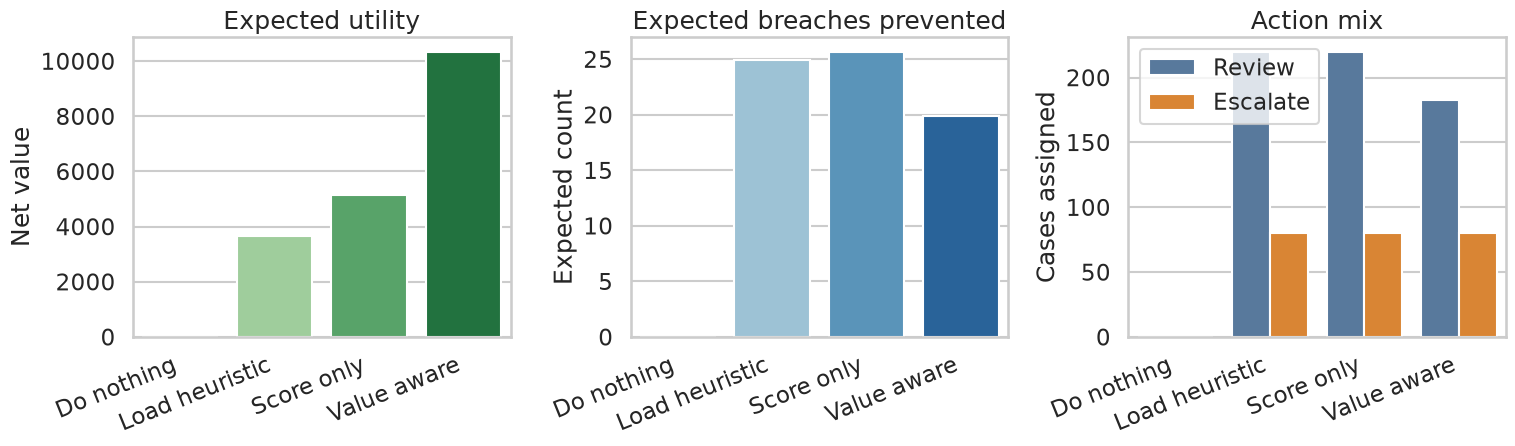

In [7]:
# Section focus: 5. Compare Policy Designs Under Capacity Constraints.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

plot_policy_table = policy_table.copy()
plot_policy_table["policy"] = plot_policy_table["policy"].map(
    {
        "none": "Do nothing",
        "load": "Load heuristic",
        "score": "Score only",
        "value": "Value aware",
    }
)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))

sns.barplot(data=plot_policy_table, x="policy", y="total_expected_utility", palette="Greens", ax=axes[0])
axes[0].set_title("Expected utility")
axes[0].set_xlabel("")
axes[0].set_ylabel("Net value")

sns.barplot(data=plot_policy_table, x="policy", y="expected_breaches_prevented", palette="Blues", ax=axes[1])
axes[1].set_title("Expected breaches prevented")
axes[1].set_xlabel("")
axes[1].set_ylabel("Expected count")

spend_long = plot_policy_table.melt(
    id_vars="policy",
    value_vars=["review_cases", "escalation_cases"],
    var_name="action",
    value_name="count",
)
spend_long["action"] = spend_long["action"].map({"review_cases": "Review", "escalation_cases": "Escalate"})

sns.barplot(data=spend_long, x="policy", y="count", hue="action", palette=["#4c78a8", "#f58518"], ax=axes[2])
axes[2].set_title("Action mix")
axes[2].set_xlabel("")
axes[2].set_ylabel("Cases assigned")
axes[2].legend(title="")

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=22, ha="right")

plt.tight_layout()
plt.show()

This comparison illustrates the central lesson of the notebook.

The same model score can support very different policies. The **score-only** rule improves on the crude workload heuristic, but the **value-aware** policy does much better because it combines risk, loss severity, and intervention effectiveness. The best recommendation policy is therefore not identical to the best ranking policy.

## 6. Capacity Frontiers

Decision quality is also capacity-dependent. If the organization can review only a small queue, the right policy may differ from the one used under a large review budget.

To study that, we vary the review capacity and compare a score-only review rule against a value-aware review rule. In both cases, we evaluate utility using the simulation's underlying risk.

,policy,review_capacity,expected_utility,acted_cases
0,Score only,50,2357.289347,50
1,Value aware,50,3893.037145,50
2,Score only,100,3337.459959,100
3,Value aware,100,5791.641304,100
4,Score only,150,3902.139164,150
5,Value aware,150,7102.985845,150
6,Score only,220,5061.693941,220
7,Value aware,220,8340.792523,220
8,Score only,300,5801.184784,300
9,Value aware,300,8679.797831,263


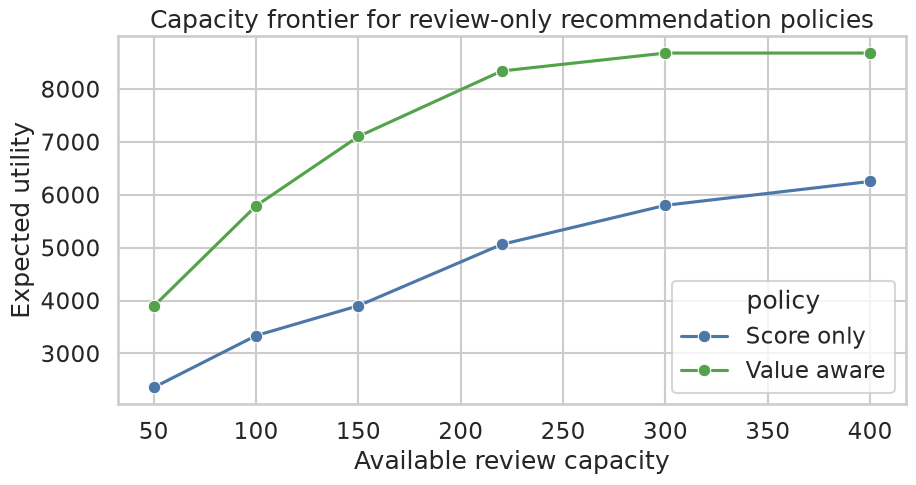

In [8]:
# Section focus: 6. Capacity Frontiers.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

frontier_records = []
for review_cap in [50, 100, 150, 220, 300, 400]:
    score_idx = current_df.sort_values("score", ascending=False).head(review_cap).index
    value_idx = (
        current_df.loc[current_df["ev_review_est"] > 0]
        .sort_values("ev_review_est", ascending=False)
        .head(review_cap)
        .index
    )

    frontier_records.append(
        {
            "policy": "Score only",
            "review_capacity": review_cap,
            "expected_utility": current_df.loc[score_idx, "ev_review_true"].sum(),
            "acted_cases": len(score_idx),
        }
    )
    frontier_records.append(
        {
            "policy": "Value aware",
            "review_capacity": review_cap,
            "expected_utility": current_df.loc[value_idx, "ev_review_true"].sum(),
            "acted_cases": len(value_idx),
        }
    )

frontier_df = pd.DataFrame(frontier_records)
display(frontier_df)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
sns.lineplot(data=frontier_df, x="review_capacity", y="expected_utility", hue="policy", marker="o", palette=["#4c78a8", "#54a24b"], ax=ax)
ax.set_title("Capacity frontier for review-only recommendation policies")
ax.set_xlabel("Available review capacity")
ax.set_ylabel("Expected utility")
plt.tight_layout()
plt.show()

The frontier makes the recommendation problem more concrete.

A score-only queue keeps expanding as capacity grows, but its marginal value eventually deteriorates. The value-aware queue saturates earlier because it stops once the remaining cases no longer have positive expected value. That is a more defensible operational policy than exhausting capacity for its own sake.

## 7. Segment-Level Recommendation Summary

We now inspect the chosen **value-aware** policy in more detail. This is the kind of summary an operations lead would want before approving deployment: who gets which action, and how concentrated is the recommendation by segment?

In [9]:
# Section focus: 7. Segment-Level Recommendation Summary.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

value_policy_df = next(result["evaluated_df"] for result in policy_results if result["policy"] == "value")

allocation_by_tier = pd.crosstab(value_policy_df["tier"], value_policy_df["action"])
allocation_by_workload = pd.crosstab(value_policy_df["high_workload"], value_policy_df["action"])
allocation_by_channel = pd.crosstab(value_policy_df["channel"], value_policy_df["action"])

print("Allocation by tier")
display(allocation_by_tier)

print("Allocation by workload regime (0 = lower, 1 = higher)")
display(allocation_by_workload)

print("Allocation by channel")
display(allocation_by_channel)

segment_gain = (
    value_policy_df.assign(
        expected_gain=np.where(
            value_policy_df["action"] == "review",
            value_policy_df["ev_review_true"],
            np.where(value_policy_df["action"] == "escalate", value_policy_df["ev_escalate_true"], 0.0),
        )
    )
    .groupby(["tier", "action"])
    .agg(cases=("seller_id", "size"), total_expected_gain=("expected_gain", "sum"), avg_score=("score", "mean"))
    .reset_index()
)

display(segment_gain)

Allocation by tier


action,escalate,none,review
tier,,,
Enterprise,80,14,95
Mid-Market,0,352,82
SMB,0,631,6


Allocation by workload regime (0 = lower, 1 = higher)


action,escalate,none,review
high_workload,,,
0,21,825,99
1,59,172,84


Allocation by channel


action,escalate,none,review
channel,,,
Chat,25,328,60
Email,39,443,99
Phone,16,226,24


,tier,action,cases,total_expected_gain,avg_score
0,Enterprise,escalate,80,6647.818376,0.263011
1,Enterprise,none,14,0.000000,0.073221
2,Enterprise,review,95,2497.335039,0.138562
3,Mid-Market,none,352,0.000000,0.116043
4,Mid-Market,review,82,1204.730467,0.235372
5,SMB,none,631,0.000000,0.135535
6,SMB,review,6,-5.437380,0.405458


These numbers translate model behavior into decision consequences. For Segment-Level Recommendation Summary, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


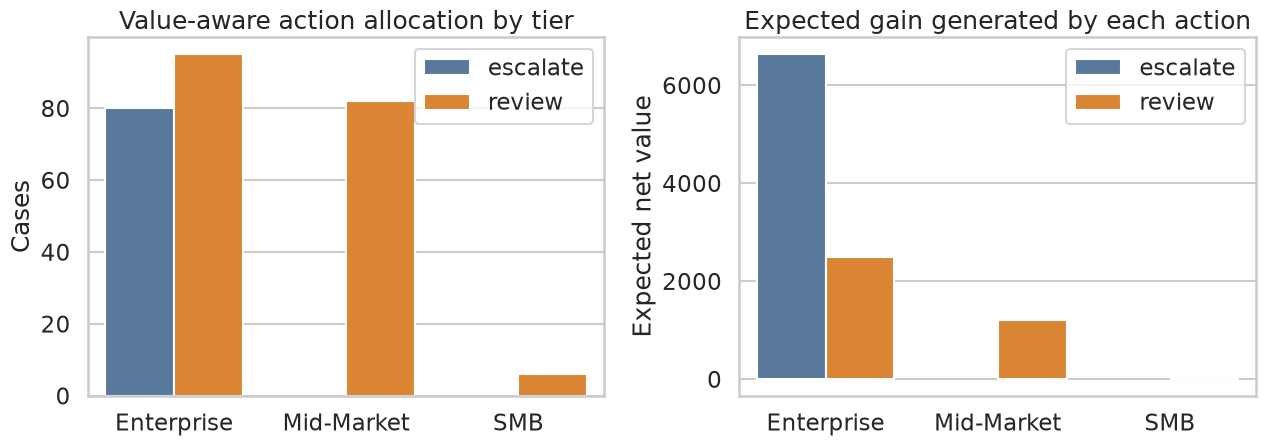

In [10]:
segment_plot = segment_gain.loc[segment_gain["action"] != "none"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(data=segment_plot, x="tier", y="cases", hue="action", palette=["#4c78a8", "#f58518"], ax=axes[0])
axes[0].set_title("Value-aware action allocation by tier")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cases")
axes[0].legend(title="")

sns.barplot(data=segment_plot, x="tier", y="total_expected_gain", hue="action", palette=["#4c78a8", "#f58518"], ax=axes[1])
axes[1].set_title("Expected gain generated by each action")
axes[1].set_xlabel("")
axes[1].set_ylabel("Expected net value")
axes[1].legend(title="")

plt.tight_layout()
plt.show()

Two features of the recommendation are worth emphasizing.

1. The policy is **selective**, not uniformly aggressive. Many cases receive no action because the expected value is negative.
2. The policy is **segment-sensitive** without relying on arbitrary quotas. Enterprise and high-workload cases receive more action because the economics justify it, not because the notebook hard-coded a preference for them.
3. A few low-value recommendations can still slip through. In this run, the tiny SMB review slice is slightly negative under the oracle benchmark, which is a good reminder that recommendation quality still depends on calibration, effect estimates, and post-deployment evaluation.

That is the difference between a recommendation layer and a mere ranking layer.

## 8. Practical Recommendation

If this were a real operational memo, the recommendation would read something like this:

1. **Use the model score as an input, not as the policy itself.**
2. **Prioritize action by expected value, not by risk alone.**
3. **Reserve escalation for the highest-value subset.** In this cohort, the economically justified escalations are concentrated in enterprise and high-workload cases.
4. **Do not force full capacity usage when marginal cases are negative value.** Spare capacity is better than negative-value interventions.
5. **Revisit the policy whenever calibration, action costs, or segment economics change.** Recommendation policy is not static even if the model architecture is unchanged.

This final point connects directly to the previous notebook. Monitoring should ask whether a model drifted and whether the action policy built on top of that model still makes sense.

## References

- Pfohl, S., Xu, Y., Foryciarz, A., et al. (2022). *Net benefit, calibration, threshold selection, and training objectives for algorithmic fairness in healthcare.* [https://doi.org/10.48550/arXiv.2202.01906](https://doi.org/10.48550/arXiv.2202.01906)
- Sadatsafavi, M., Adibi, A., & Puhan, M. A. (2021). *Moving beyond AUC: decision curve analysis for quantifying net benefit of risk prediction models.* *European Respiratory Journal*, 58(5), 2101186. [https://doi.org/10.1183/13993003.01186-2021](https://doi.org/10.1183/13993003.01186-2021)
- Vickers, A. J., Van Calster, B., & Steyerberg, E. W. (2016). *Net benefit approaches to the evaluation of prediction models, molecular markers, and diagnostic tests.* *BMJ*, i6. [https://doi.org/10.1136/bmj.i6](https://doi.org/10.1136/bmj.i6)
